<a href="https://colab.research.google.com/github/Siddhigandhi854/Generative-AI/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational Autoencoder (VAE) on MNIST

**Goal:** Train a Variational Autoencoder on MNIST and save the trained **VAE, Encoder, and Decoder** so the Decoder can later be used in a **VS Code + Flask + HTML/CSS** project to generate new handwritten digits.

### Learning path
1. Load and preprocess MNIST
2. Build the Encoder
3. Understand μ and log(σ²)
4. Apply the Reparameterization Trick
5. Build the Decoder
6. Calculate Reconstruction Loss + KL Divergence
7. Train using Backpropagation
8. Visualize reconstructions and latent space
9. Generate new images
10. Save models for a Flask project

## 1. VAE Architecture

```text
Input image (28×28)
        │
        ▼
     Encoder
        │
   ┌────┴────┐
   ▼         ▼
   μ      log(σ²)
   │         │
   └────┬────┘
        ▼
 z = μ + σ × ε
        │
        ▼
     Decoder
        │
        ▼
Reconstructed image

Training:
VAE Loss = Reconstruction Loss + KL Divergence

Generation after training:
Random z → Trained Decoder → New image
```

For the future Flask application, **the trained Decoder is the key model for generation**.


In [1]:
# 2. Imports and environment check

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Load and preprocess MNIST

MNIST contains grayscale handwritten digits.

- Image size: 28 × 28
- Pixel values: 0–255
- Normalize to 0–1
- Labels are not required for this unsupervised VAE


In [2]:
# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


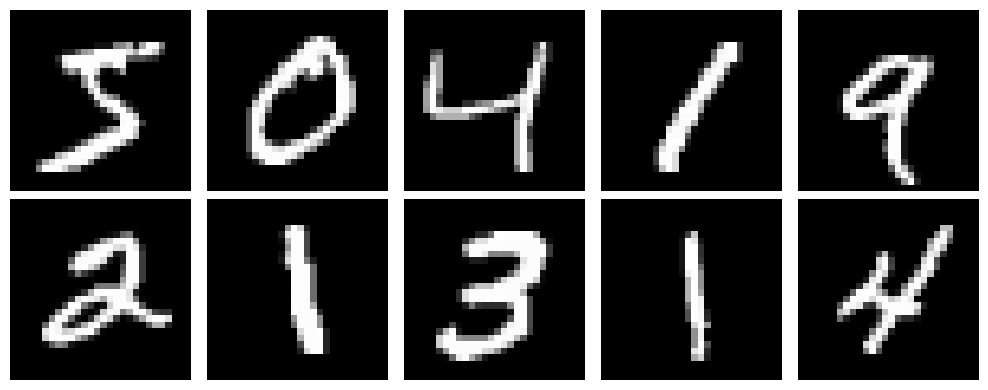

In [3]:
# Display sample images

plt.figure(figsize=(10, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 4. VAE Configuration

We choose a **2-dimensional latent space** so that it is easy to visualize.

- Original image: 28×28 = 784 values
- Latent representation: 2 values
- Batch size: 128
- Epochs: 30

You can increase the number of epochs later for experimentation.


In [4]:
original_dim = 28 * 28
latent_dim = 2
batch_size = 128
epochs = 30

print("Original dimension:", original_dim)
print("Latent dimension:", latent_dim)

Original dimension: 784
Latent dimension: 2


# 5. Build the Encoder

The Encoder converts an image into two outputs:

- **μ (z_mean)** — mean of the latent distribution
- **log(σ²) (z_log_var)** — logarithm of variance

```text
28×28×1
   ↓
Flatten
   ↓
Dense layers
   ↓
 ┌───────┴───────┐
 ▼               ▼
μ             log(σ²)
```


In [5]:
# Encoder

encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")

x = layers.Flatten(name="flatten")(encoder_inputs)
x = layers.Dense(256, activation="relu", name="encoder_dense_1")(x)
x = layers.Dense(128, activation="relu", name="encoder_dense_2")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="encoder"
)

encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 256)       │    200,960 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 128)       │     32,896 │ encoder_dense_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ encoder_dense_2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Reparameterization Trick

The VAE samples a latent vector using:

\[
z = \mu + \sigma\epsilon
\]

where:

- μ = mean
- σ = standard deviation
- ε = random noise from N(0, 1)

Because the Encoder outputs `log(σ²)`:

\[
\sigma = e^{0.5\log(\sigma^2)}
\]

This form allows gradient-based learning through the sampling step.


In [6]:
# Reparameterization function

def sample_latent(z_mean, z_log_var):
    epsilon = tf.random.normal(
        shape=tf.shape(z_mean),
        mean=0.0,
        stddev=1.0
    )
    sigma = tf.exp(0.5 * z_log_var)
    z = z_mean + sigma * epsilon
    return z


# 7. Build the Decoder

The Decoder converts the latent vector back into a 28×28 image.

```text
z (2 values)
   ↓
Dense layers
   ↓
784 values
   ↓
Reshape
   ↓
28×28×1 image
```

**This Decoder will later be saved and used by Flask for image generation.**


In [7]:
# Decoder

latent_inputs = keras.Input(
    shape=(latent_dim,),
    name="decoder_input"
)

# Layer 1
x = layers.Dense(
    128,
    activation="relu",
    name="decoder_dense_1"
)(latent_inputs)

# Layer 2
x = layers.Dense(
    256,
    activation="relu",
    name="decoder_dense_2"
)(x)

# Layer 3
x = layers.Dense(
    28 * 28,
    activation="sigmoid",
    name="decoder_output_flat"
)(x)   # <-- IMPORTANT

# Convert 784 values back to 28 × 28 × 1
decoder_outputs = layers.Reshape(
    (28, 28, 1),
    name="decoder_output"
)(x)

# Create Decoder model
decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output_flat (Dense)     │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Reshape)        │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Create the VAE and its loss

The total loss is:

\[
L_{VAE}=L_{reconstruction}+L_{KL}
\]

- **Reconstruction loss:** how close the output is to the input.
- **KL divergence:** encourages the learned latent distribution to stay close to N(0, I).

The custom `train_step()` below performs:
**forward pass → loss calculation → backpropagation → weight update**.


In [8]:
# Complete VAE model

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = sample_latent(z_mean, z_log_var)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            bce = keras.losses.binary_crossentropy(
                data, reconstruction
            )
            reconstruction_loss = tf.reduce_sum(bce, axis=(1, 2))
            reconstruction_loss = tf.reduce_mean(reconstruction_loss)

            # KL divergence
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)

            total_loss = reconstruction_loss + kl_loss

        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Weight update
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = sample_latent(z_mean, z_log_var)
        return self.decoder(z)


vae = VAE(encoder, decoder, name="vae")
vae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3)
)

print("VAE created successfully.")


VAE created successfully.


# 9. Train the VAE

Training loop:

```text
Input
 ↓
Encoder
 ↓
μ, log(σ²)
 ↓
Reparameterization
 ↓
z
 ↓
Decoder
 ↓
Reconstruction
 ↓
Loss
 ↓
Backpropagation
 ↓
Weight update
```

For a first experiment, 30 epochs is a good starting point.


In [9]:
# Train

history = vae.fit(
    x_train,
    epochs=epochs,
    batch_size=batch_size
)


Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.2863 - loss: 193.8769 - reconstruction_loss: 188.5907
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.8022 - loss: 168.6746 - reconstruction_loss: 163.8724
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1106 - loss: 162.4675 - reconstruction_loss: 157.3568
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3197 - loss: 159.1589 - reconstruction_loss: 153.8391
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.4793 - loss: 156.6144 - reconstruction_loss: 151.1351
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6427 - loss: 154.3692 - reconstruction_loss: 148.7266
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.7564 - loss: 152.4520 - reconstruction_loss: 146.6957
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.8595 - loss: 150.9753 - reconstruction_loss: 145.1159
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

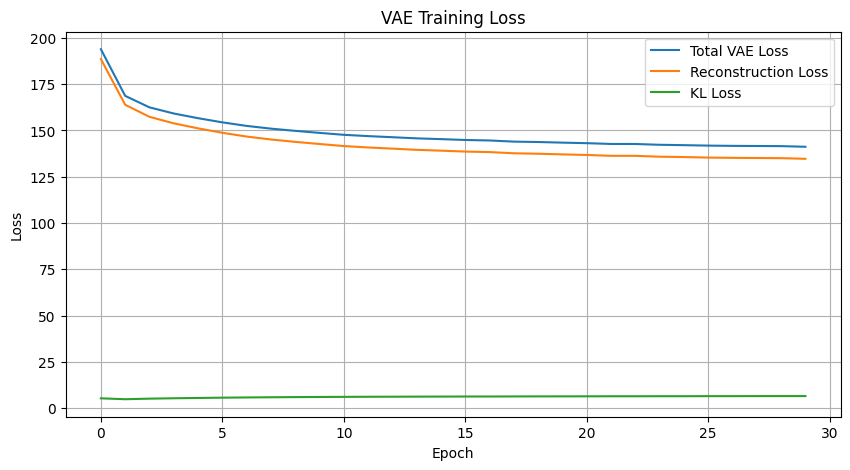

In [10]:
# Plot training losses

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Total VAE Loss")
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()


# 10. Reconstruction Results

Here we start with an existing image and reconstruct it:

```text
Image → Encoder → z → Decoder → Reconstruction
```


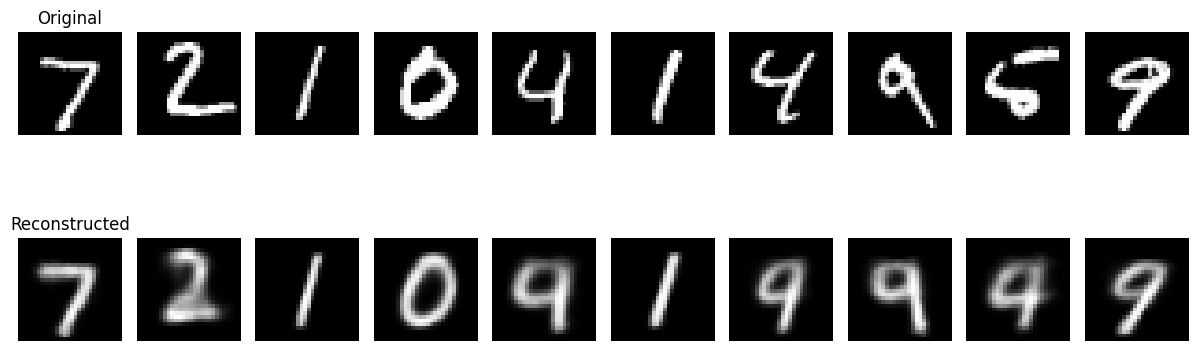

In [11]:
# Reconstruct test images

z_mean_test, z_log_var_test = encoder.predict(
    x_test[:10], verbose=0
)

z_test = sample_latent(
    z_mean_test, z_log_var_test
)

reconstructed = decoder.predict(
    z_test, verbose=0
)

plt.figure(figsize=(12, 5))

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed")

plt.tight_layout()
plt.show()


# 11. Visualize the Latent Space

Because `latent_dim = 2`, every image can be represented as a point `(z1, z2)`.

This gives a visual demonstration of **latent space**.


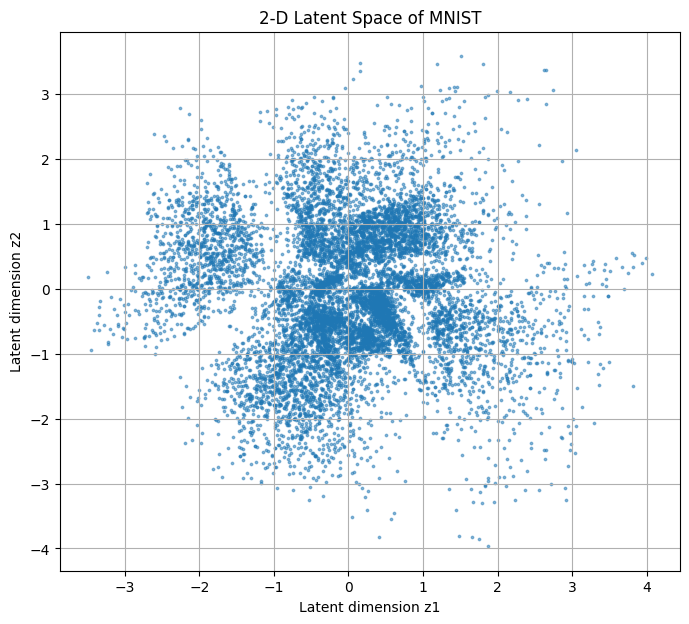

In [12]:
# Plot latent means

z_mean_all, z_log_var_all = encoder.predict(
    x_test, verbose=0
)

plt.figure(figsize=(8, 7))
plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    s=3,
    alpha=0.5
)
plt.xlabel("Latent dimension z1")
plt.ylabel("Latent dimension z2")
plt.title("2-D Latent Space of MNIST")
plt.grid(True)
plt.show()


# 12. Generate New Images

This is the key generative step.

We do **not** start with an input image.

Instead:

\[
z \sim N(0,I)
\]

Then:

```text
Random z
   ↓
Trained Decoder
   ↓
New MNIST-like image
```


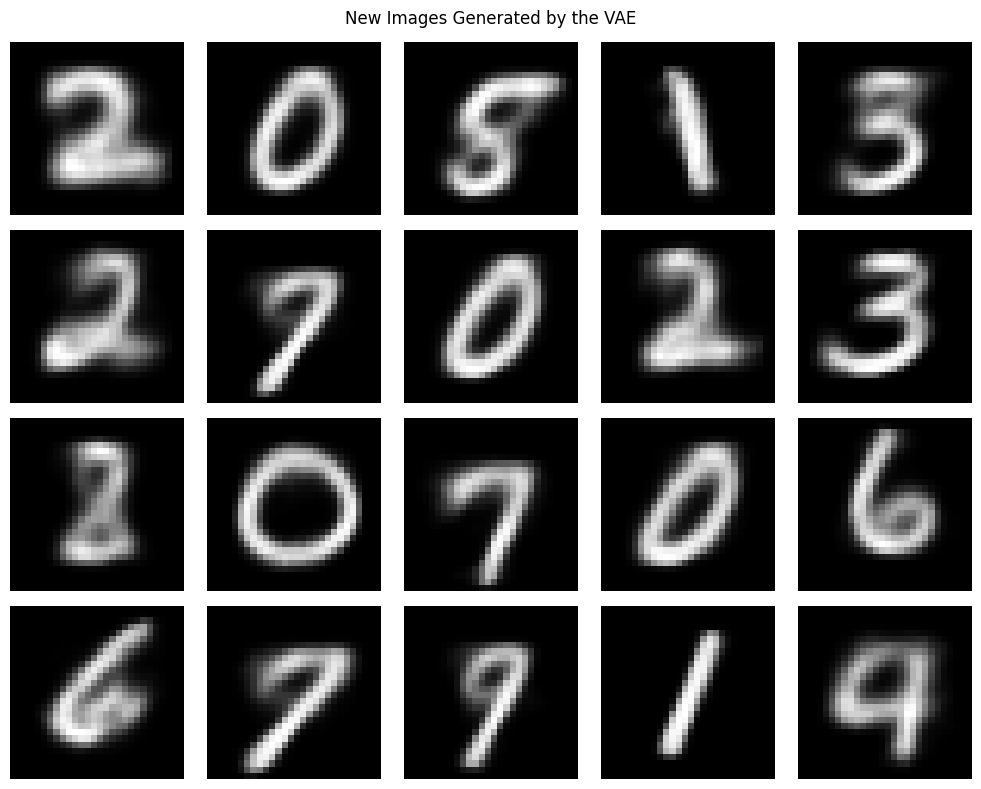

In [13]:
# Generate 20 new images

num_images = 20

random_z = tf.random.normal(
    shape=(num_images, latent_dim)
)

generated_images = decoder.predict(
    random_z,
    verbose=0
)

plt.figure(figsize=(10, 8))

for i in range(num_images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("New Images Generated by the VAE")
plt.tight_layout()
plt.show()


 13. Generate One Image from a Latent Vector

This is almost exactly what the future Flask application will do.

```text
Generate button
      ↓
Random z
      ↓
Saved Decoder
      ↓
Generated image
```


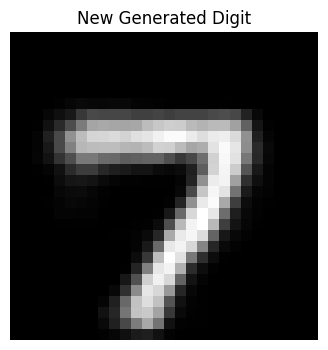

In [14]:
# Generate one image

z = tf.random.normal(shape=(1, latent_dim))

new_image = decoder.predict(
    z,
    verbose=0
)[0]

plt.figure(figsize=(4, 4))
plt.imshow(new_image.squeeze(), cmap="gray")
plt.axis("off")
plt.title("New Generated Digit")
plt.show()


# 14. Save the Models

We save:

### `vae_mnist.keras`
Complete VAE.

### `vae_encoder.keras`
Encoder only.

### `vae_decoder.keras` ⭐
Decoder only — **the most important file for the Flask generation project**.

The future Flask app can load the Decoder and generate an image from a random latent vector without running the Encoder.


In [15]:
# Save Encoder and Decoder

SAVE_DIR = "/content/vae_mnist_models"
os.makedirs(SAVE_DIR, exist_ok=True)

encoder_path = os.path.join(
    SAVE_DIR,
    "vae_encoder.keras"
)

decoder_path = os.path.join(
    SAVE_DIR,
    "vae_decoder.keras"
)

# Make sure the models are built before saving
_ = encoder(x_train[:1])
_ = decoder(tf.zeros((1, latent_dim)))

# Save Functional Keras models
encoder.save(encoder_path)
decoder.save(decoder_path)

print("Models saved successfully!")
print()
print("Encoder :", encoder_path)
print("Decoder :", decoder_path)

Models saved successfully!

Encoder : /content/vae_mnist_models/vae_encoder.keras
Decoder : /content/vae_mnist_models/vae_decoder.keras


# 15. Verify the Saved Decoder

Always test the saved model before downloading it.


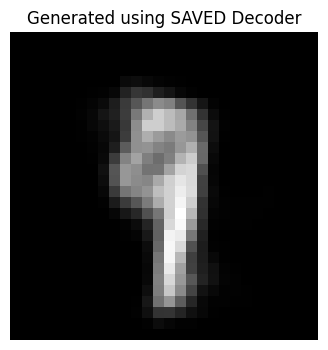

In [16]:
# Load saved decoder and generate a test image

loaded_decoder = keras.models.load_model(
    decoder_path
)

test_z = tf.random.normal(shape=(1, latent_dim))

test_image = loaded_decoder.predict(
    test_z,
    verbose=0
)[0]

plt.figure(figsize=(4, 4))
plt.imshow(test_image.squeeze(), cmap="gray")
plt.axis("off")
plt.title("Generated using SAVED Decoder")
plt.show()


# 16. Package the Models into a ZIP file

The ZIP will contain:

```text
vae_mnist_models/
├── vae_mnist.keras
├── vae_encoder.keras
└── vae_decoder.keras
```

Download it and put the Decoder in your future Flask project's `models/` folder.


In [17]:
# Create ZIP archive

import shutil

zip_path = shutil.make_archive(
    "/content/vae_mnist_models",
    "zip",
    SAVE_DIR
)

print("ZIP created:", zip_path)


ZIP created: /content/vae_mnist_models.zip


In [18]:
# Download ZIP to your computer

from google.colab import files

files.download("/content/vae_mnist_models.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 17. Future Flask Project Structure

After downloading and extracting:

```text
vae_flask_project/
│
├── app.py
│
├── models/
│   └── vae_decoder.keras
│
├── templates/
│   └── index.html
│
└── static/
    └── style.css
```

The generation flow will be:

```text
HTML/CSS
  │
  │ Generate button
  ▼
Flask
  │
  ▼
Random latent z ~ N(0,I)
  │
  ▼
vae_decoder.keras
  │
  ▼
28×28 generated image
  │
  ▼
PNG
  │
  ▼
Browser
```


**PART 2: Create HTML/CSS file index.html for UI**

In [ ]:
<!DOCTYPE html>

<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>VAE MNIST Digit Generator</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='style.css') }}">

</head>


<body>


<div class="container">


    <div class="card">


        <h1>VAE Digit Generator</h1>


        <p class="subtitle">

            Select a number and generate a new
            MNIST-style handwritten image using the
            trained VAE Decoder.

        </p>


        <!-- Digit Selection -->

        <div class="section">

            <h2>Select a Digit</h2>


            <div class="digit-grid">

                <button class="digit-btn active" data-digit="0">
                    0
                </button>

                <button class="digit-btn" data-digit="1">
                    1
                </button>

                <button class="digit-btn" data-digit="2">
                    2
                </button>

                <button class="digit-btn" data-digit="3">
                    3
                </button>

                <button class="digit-btn" data-digit="4">
                    4
                </button>

                <button class="digit-btn" data-digit="5">
                    5
                </button>

                <button class="digit-btn" data-digit="6">
                    6
                </button>

                <button class="digit-btn" data-digit="7">
                    7
                </button>

                <button class="digit-btn" data-digit="8">
                    8
                </button>

                <button class="digit-btn" data-digit="9">
                    9
                </button>

            </div>

        </div>


        <!-- Selected Digit -->

        <div class="selected-info">

            Selected Number:

            <span id="selectedDigit">
                0
            </span>

        </div>


        <!-- Generate Button -->

        <button id="generateBtn">

            Generate Image

        </button>


        <!-- Loading -->

        <div id="loading"
             class="loading hidden">

            Generating image...

        </div>


        <!-- Generated Image -->

        <div class="image-section">


            <h2>Generated Image</h2>


            <div class="image-box">


                <img
                    id="generatedImage"
                    src=""
                    alt="Generated digit"
                >


                <p id="placeholder">

                    Your generated image will appear here

                </p>


            </div>


        </div>


    </div>


</div>



<script>


let selectedDigit = 0;


const digitButtons =
    document.querySelectorAll(".digit-btn");


const selectedDigitText =
    document.getElementById("selectedDigit");


const generateBtn =
    document.getElementById("generateBtn");


const generatedImage =
    document.getElementById("generatedImage");


const placeholder =
    document.getElementById("placeholder");


const loading =
    document.getElementById("loading");



/* ------------------------------------------
   Select Digit
------------------------------------------ */

digitButtons.forEach(function(button) {

    button.addEventListener("click", function() {


        // Remove active class
        digitButtons.forEach(function(btn) {

            btn.classList.remove("active");

        });


        // Add active class
        this.classList.add("active");


        // Store selected digit
        selectedDigit =
            parseInt(this.dataset.digit);


        // Display selected digit
        selectedDigitText.textContent =
            selectedDigit;

    });

});



/* ------------------------------------------
   Generate Image
------------------------------------------ */

generateBtn.addEventListener(
    "click",
    async function() {


        loading.classList.remove("hidden");


        generateBtn.disabled = true;


        try {


            const response =
                await fetch("/generate", {

                    method: "POST",

                    headers: {

                        "Content-Type":
                            "application/json"

                    },

                    body: JSON.stringify({

                        digit: selectedDigit

                    })

                });


            const data =
                await response.json();


            if (data.success) {


                generatedImage.src =
                    "data:image/png;base64,"
                    + data.image;


                generatedImage.style.display =
                    "block";


                placeholder.style.display =
                    "none";


            }

            else {

                alert(
                    "Error: "
                    + data.error
                );

            }


        }

        catch (error) {

            alert(
                "Something went wrong: "
                + error
            );

        }


        finally {


            loading.classList.add(
                "hidden"
            );


            generateBtn.disabled =
                false;


        }


    }
);


</script>


</body>

</html>

**PART 3: FLASK CODE as app.py**

In [ ]:
from flask import Flask, render_template, request, jsonify
import tensorflow as tf
import numpy as np
import base64
import io

from PIL import Image


app = Flask(__name__)


# --------------------------------------------------
# Load the trained VAE Decoder
# --------------------------------------------------

MODEL_PATH = "models/vae_decoder.keras"

decoder = tf.keras.models.load_model(MODEL_PATH)

print("VAE Decoder loaded successfully!")
print("Decoder input shape:", decoder.input_shape)
print("Decoder output shape:", decoder.output_shape)


# --------------------------------------------------
# Home Page
# --------------------------------------------------

@app.route("/")
def home():
    return render_template("index.html")


# --------------------------------------------------
# Generate Image
# --------------------------------------------------

@app.route("/generate", methods=["POST"])
def generate():

    try:

        # Get selected digit from UI
        data = request.get_json()

        selected_digit = int(data.get("digit", 0))

        # Validate digit
        if selected_digit < 0 or selected_digit > 9:
            return jsonify({
                "success": False,
                "error": "Please select a number between 0 and 9."
            }), 400


        # --------------------------------------------------
        # Generate random latent vector
        #
        # Your VAE was trained with latent_dim = 2
        # --------------------------------------------------

        latent_dim = 2

        z = tf.random.normal(
            shape=(1, latent_dim),
            mean=0.0,
            stddev=1.0
        )


        # --------------------------------------------------
        # Generate image using decoder
        # --------------------------------------------------

        generated_image = decoder.predict(
            z,
            verbose=0
        )[0]


        # Remove channel dimension
        generated_image = generated_image.squeeze()


        # Convert values from 0-1 to 0-255
        generated_image = (
            generated_image * 255
        ).astype(np.uint8)


        # --------------------------------------------------
        # Convert image to PNG
        # --------------------------------------------------

        image = Image.fromarray(
            generated_image,
            mode="L"
        )

        buffer = io.BytesIO()

        image.save(
            buffer,
            format="PNG"
        )

        buffer.seek(0)


        # Convert image to Base64
        image_base64 = base64.b64encode(
            buffer.getvalue()
        ).decode("utf-8")


        return jsonify({
            "success": True,
            "selected_digit": selected_digit,
            "image": image_base64
        })


    except Exception as e:

        print("ERROR:", str(e))

        return jsonify({
            "success": False,
            "error": str(e)
        }), 500


# --------------------------------------------------
# Run Flask Application
# --------------------------------------------------

if __name__ == "__main__":

    app.run(
        debug=True,
        host="127.0.0.1",
        port=5000
    )

# **Alternative way to save the model**

In [19]:
import pickle

# Save decoder model using pickle
with open("vae_decoder.pkl", "wb") as file:
    pickle.dump(decoder, file)

print("Decoder model saved successfully as vae_decoder.pkl")

Decoder model saved successfully as vae_decoder.pkl
